In [2]:
#DNN建立
# 统一部分
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F

print(sys.version_info)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=13, micro=5, releaselevel='final', serial=0)
cuda:0


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

print(len(train_dataset))
print(len(test_dataset))

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(class_names)
print(len(class_names))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,num_workers=4)


100%|██████████| 9.91M/9.91M [02:46<00:00, 59.4kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [01:18<00:00, 20.9kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.14MB/s]

60000
10000
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
10


In [4]:
#DNN建立

import torch
import torch.nn as nn
import torch.nn.functional as F

class DNN(nn.Module):
    def __init__(self, input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10):
        super(DNN, self).__init__()

        layers = []
        
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.ReLU())
        
        for i in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.ReLU())
        
        layers.append(nn.Linear(hidden_size, num_classes))
        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.layers(x)
        return x
    
model = DNN(input_size = 784, hidden_size = 256, output_size = 10, num_hidden_layers = 19, num_classes = 10)

print(model)
print(sum(p.numel() for p in model.parameters()))

DNN(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): ReLU()
    (10): Linear(in_features=256, out_features=256, bias=True)
    (11): ReLU()
    (12): Linear(in_features=256, out_features=256, bias=True)
    (13): ReLU()
    (14): Linear(in_features=256, out_features=256, bias=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=256, bias=True)
    (17): ReLU()
    (18): Linear(in_features=256, out_features=256, bias=True)
    (19): ReLU()
    (20): Linear(in_features=256, out_features=256, bias=True)
    (21): ReLU()
    (22): Linear(in_features=256, out_features=256, bias=True)
    (23): ReLU()
    (24): Linear(in_f

In [ ]:
batch_size = 64
input_tensor = torch.randn(batch_size, 1, 28, 28)

print(input_tensor.shape)

with torch.no_grad():
    output = model(input_tensor)

print(output.shape)

assert output.shape == (batch_size, 10), f"期望输出形状为 ({batch_size}, 10), 但得到 {output.shape}"
print("测试通过")

for batch in train_loader:
    inputs, targets = batch
    print(inputs.shape)
    print(targets.shape)
    break

from my_trainer_for_t1 import Trainer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

early_stopping_kwargs = {
    'patience': 10,
    'min_delta': 0.001,
    'mode': 'max'
}

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500
)

trainer.train(num_epochs=20)

torch.Size([64, 1, 28, 28])
torch.Size([64, 10])
测试通过
torch.Size([64, 1, 28, 28])
torch.Size([64])
使用设备: cuda
[Step 500] Val Loss: 0.9792 Val Acc: 0.6568
Epoch [1/20]  Train Loss: 1.4287  Train Acc: 0.4459
[Step 1000] Val Loss: 0.9434 Val Acc: 0.6641
[Step 1500] Val Loss: 0.6178 Val Acc: 0.7948
Epoch [2/20]  Train Loss: 0.7938  Train Acc: 0.7319
[Step 2000] Val Loss: 0.6694 Val Acc: 0.7807
[Step 2500] Val Loss: 0.9397 Val Acc: 0.6419
Epoch [3/20]  Train Loss: 0.7553  Train Acc: 0.7541
[Step 3000] Val Loss: 0.6038 Val Acc: 0.8127
[Step 3500] Val Loss: 0.5544 Val Acc: 0.8302
Epoch [4/20]  Train Loss: 0.6900  Train Acc: 0.7933
[Step 4000] Val Loss: 0.5065 Val Acc: 0.8676
[Step 4500] Val Loss: 0.9416 Val Acc: 0.7003
Epoch [5/20]  Train Loss: 0.9761  Train Acc: 0.6780
[Step 5000] Val Loss: 1.0086 Val Acc: 0.6859
[Step 5500] Val Loss: 0.7713 Val Acc: 0.7834
Epoch [6/20]  Train Loss: 0.8902  Train Acc: 0.7285
[Step 6000] Val Loss: 0.7764 Val Acc: 0.8136
[Step 6500] Val Loss: 0.6718 Val Acc: 0

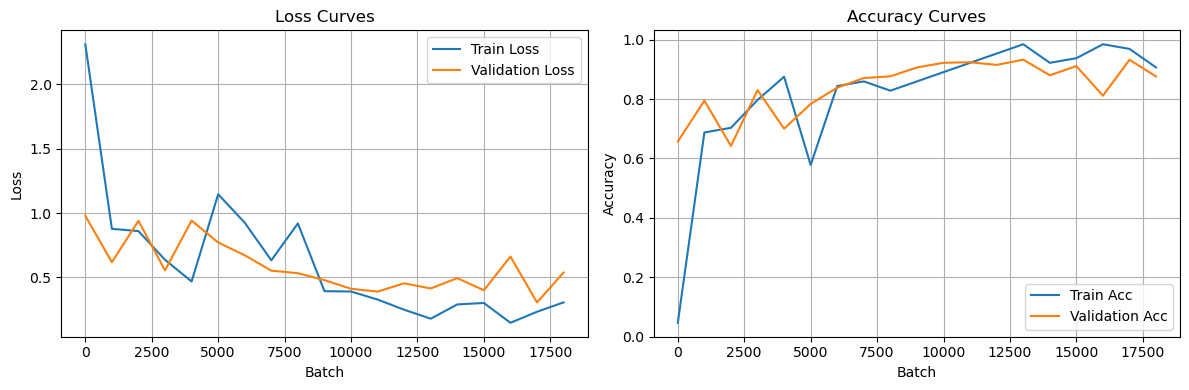

In [7]:
trainer.plot_curves()